In [22]:
import os
import rioxarray as rxr
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import geopandas as gpd
from osgeo import gdal
gdal.UseExceptions()
import importlib
import sys

sys.path.append('../scripts')
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [23]:
##Be sure to update these file paths. These shapefiles are in the date template
mcs_shp = gpd.read_file(
    "C:/Users/13038/Desktop/SIRO/shapes/MCS_outline.shp"
)

basin_shp = gpd.read_file(
    "C:/Users/13038/Desktop/SIRO/shapes/basin_outline.shp"
)


In [24]:
task1_raw_data = get_raw_data("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 1)
task2_raw_data = get_raw_data("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 2)
task1 = process_all_dates("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 1)
task2 = process_all_dates("C:/Users/13038/Desktop/SIRO/Model_Outputs/dates/dates", 2)


In [25]:
regressions = []

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

for key in task1.keys():
    lidar_100 = task1[key]['lidar']
    lidar_2000 = task1[key]['lidar_2000']

    lidar_100 = rxr.open_rasterio(lidar_100, masked=True).squeeze()
    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(lidar_2000, masked=True).squeeze()
    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    resample_tasks = {"Task 1": task1[key]['resample'], "Task 2": task2[key]['resample']}


    # 3. Iterate through tasks and models, using the in-memory LiDAR data
    for task_name, resampled_models in resample_tasks.items():
        for model_name, model_path in resampled_models.items():
            # Open the modeled raster
            modeled = rxr.open_rasterio(model_path, masked=True).squeeze()
            modeled_flat = modeled.values.flatten()

            # Assign the correct LiDAR data (already in memory)
            if "HMS" in model_name:
                lidar_flat = lidar_2000_flat
            else:
                lidar_flat = lidar_100_flat

            # Prepare data for regression by removing NaN values
            mask = ~np.isnan(lidar_flat) & ~np.isnan(modeled_flat)
            x_clean = lidar_flat[mask]
            y_clean = modeled_flat[mask]

            # Perform regression if there is data to compare
            if len(x_clean) > 1 and len(y_clean) > 1:
                regression_result = linregress(x_clean, y_clean)
                rmse = rmse_numpy(x_clean, y_clean)

                row = {
                    "Task": task_name,
                    "Conditions": "Data Assimilation" if task_name == "Task 2" else "Baseline",
                    "Date": key,
                    "Model": model_name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr,
                    "RMSE": rmse
                }
                regressions.append(row)

# 4. Create the final DataFrame and save to CSV
df = pd.DataFrame(regressions)
if 'rvalue' in df.columns:
    df['r-squared'] = df['rvalue']**2
df.to_csv('outputs/regression_results.csv', index=False)


In [ ]:
df_filtered_isno = df[(df['Model'] == 'iSnobal') | (df['Model'] == 'SnowModel')]
df_filtered_hms = df[(df['Model'] == 'HMS-Energy-Balance') | (df['Model'] == 'HMS-Temperature-Index')]

C:\Users\13038\AppData\Local\Temp\ipykernel_10352\101723611.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


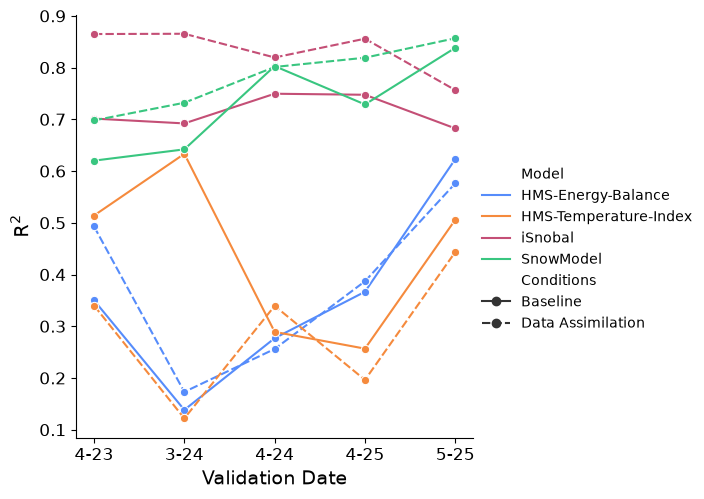

In [34]:

g = sns.relplot(
    data=df,
    x='Date',
    y='r-squared',
    hue='Model',
    style='Conditions',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", 
                  "R$^2$", 
                  fontsize=14
                  )
g.tick_params(axis='both', which='major', 
              labelsize=12
              )
g._legend.set_title("")
plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/r-squared.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\13038\AppData\Local\Temp\ipykernel_10352\358496137.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


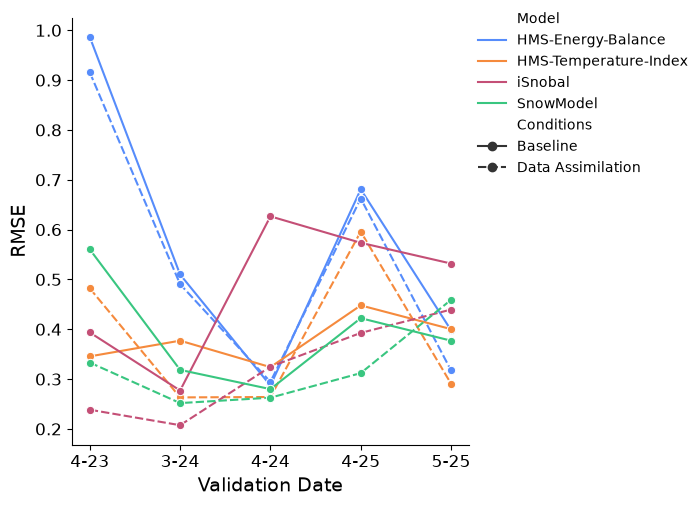

In [49]:

g = sns.relplot(
    data=df,
    x='Date',
    y='RMSE',
    hue='Model',
    style='Conditions',
    kind='line',
    markers = 'o')

sns.move_legend(g,
                "upper right",
                #fontsize=14
                )
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", "RMSE",
                  fontsize=14
                  )
g.tick_params(axis='both', which='major', 
              labelsize=12
              )
plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/RMSE.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\13038\AppData\Local\Temp\ipykernel_10352\359256188.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(
C:\Users\13038\AppData\Local\Temp\ipykernel_10352\359256188.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[0].set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
C:\Users\13038\AppData\Local\Temp\ipykernel_10352\359256188.py:16: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(
C:\Users\13038\AppData\Local\Temp\ipykernel_10352\359256188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[1].set_xticklabels(['4-23', '3-24', '4-24', '4

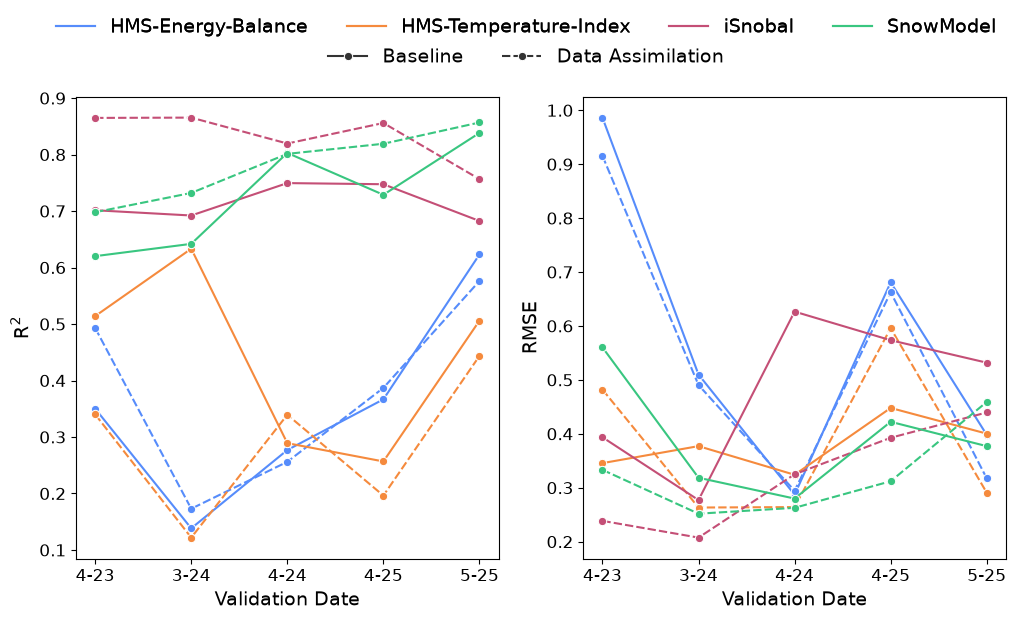

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Panel 1: R^2 ---
sns.lineplot(
    data=df, x='Date', y='r-squared',
    hue='Model', style='Conditions',
    markers='o', dashes=True,
    ax=axs[0],
)
axs[0].set_xlabel("Validation Date", fontsize=14)
axs[0].set_ylabel("R$^2$", fontsize=14)
axs[0].set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
axs[0].tick_params(axis='both', which='major', labelsize=12)

# --- Panel 2: RMSE ---
sns.lineplot(
    data=df, x='Date', y='RMSE',
    hue='Model', style='Conditions',
    markers='o', dashes=True,
    ax=axs[1], legend=False,
)
axs[1].set_xlabel("Validation Date", fontsize=14)
axs[1].set_ylabel("RMSE", fontsize=14)
axs[1].set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
axs[1].tick_params(axis='both', which='major', labelsize=12)

# --- Build one legend, split into a Model row and a Conditions row, headers dropped ---
handles, labels = axs[0].get_legend_handles_labels()
axs[0].get_legend().remove()

split_idx = labels.index("Conditions")
model_handles, model_labels = handles[1:split_idx], labels[1:split_idx]   # drop "Model" header
cond_handles, cond_labels = handles[split_idx + 1:], labels[split_idx + 1:]  # drop "Conditions" header

leg1 = fig.legend(model_handles, model_labels, loc='lower center', ncol=len(model_labels),
                   bbox_to_anchor=(0.5, 0.95), frameon=False, fontsize=14)
fig.add_artist(leg1)
fig.legend(cond_handles, cond_labels, loc='lower center', ncol=len(cond_labels),
           bbox_to_anchor=(0.5, 0.9), frameon=False, fontsize=14)

#plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/r2_RMSE_combined.png",
    dpi=300,
    bbox_inches='tight',
)
plt.show()

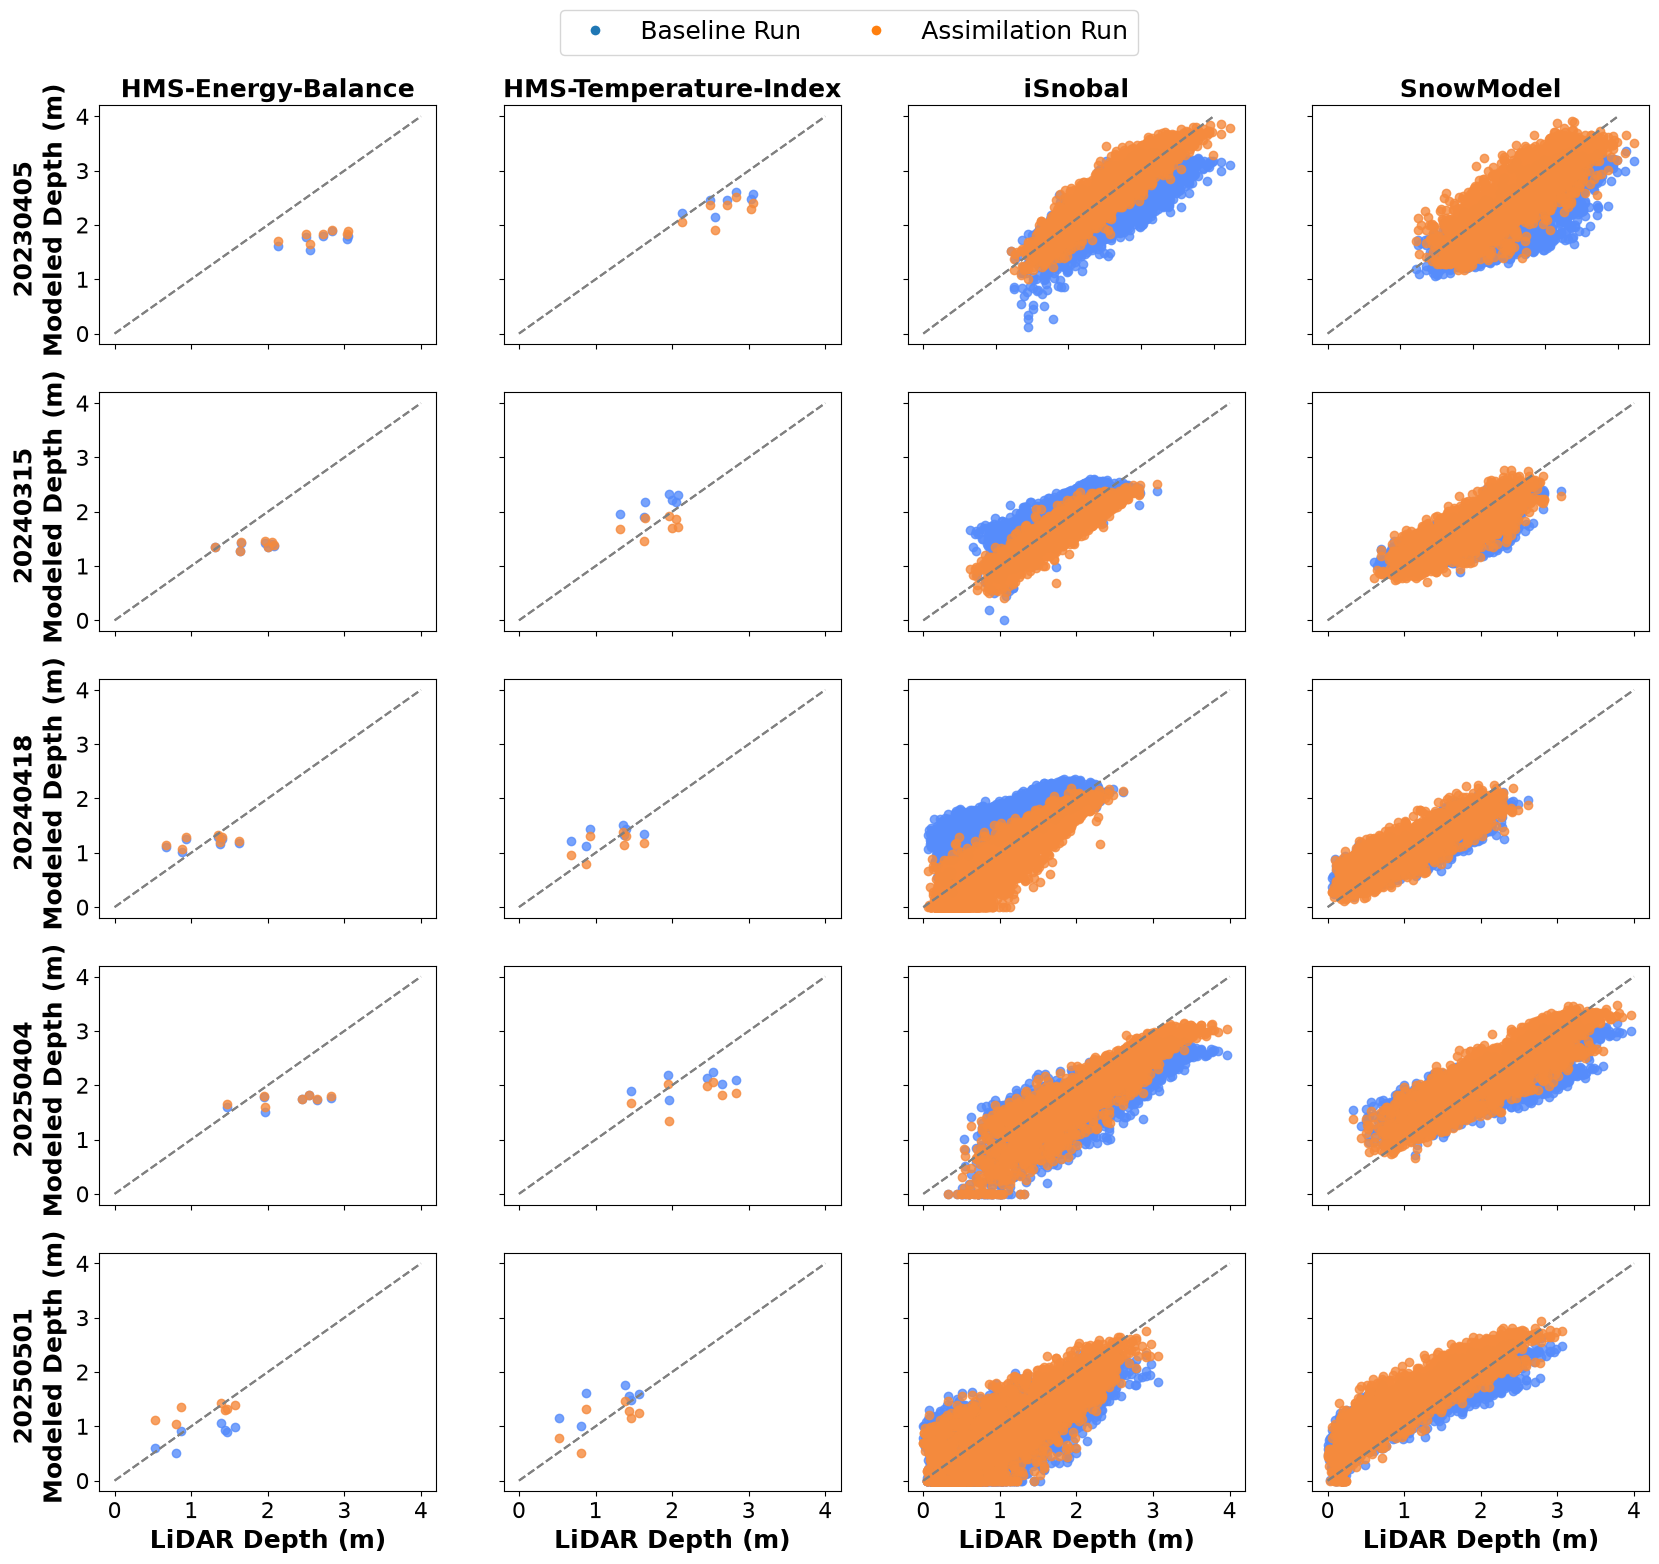

In [32]:
from matplotlib.lines import Line2D


models = [
    "HMS-Energy-Balance",
    "HMS-Temperature-Index",
    "iSnobal",
    "SnowModel"
]

fig, axs = plt.subplots(
    nrows=len(task1),
    ncols=len(models),
    figsize=(20, 18),
    sharey=True
)

for row, date in enumerate(task1.keys()):

    # Load lidar once per date
    lidar_100 = rxr.open_rasterio(
        task1[date]["lidar"],
        masked=True
    ).squeeze()

    lidar_100 = lidar_100.where(lidar_100 < 5)
    lidar_100_flat = lidar_100.values.flatten()

    lidar_2000 = rxr.open_rasterio(
        task1[date]["lidar_2000"],
        masked=True
    ).squeeze()

    lidar_2000 = lidar_2000.where(lidar_2000 < 5)
    lidar_2000_flat = lidar_2000.values.flatten()

    for col, model in enumerate(models):
        ax = axs[row, col]
        ax.tick_params(axis='both', labelsize=16)
        # Choose correct lidar resolution
        if "HMS" in model:
            lidar_flat = lidar_2000_flat
        else:
            lidar_flat = lidar_100_flat

        # ----- Task 1 -----
        model1 = rxr.open_rasterio(
            task1[date]["resample"][model],
            masked=True
        ).squeeze()

        y1 = model1.values.flatten()

        mask1 = np.isfinite(lidar_flat) & np.isfinite(y1)

        sns.regplot(
            x=lidar_flat[mask1],
            y=y1[mask1],
            fit_reg=False,
            ax=ax,
            #scatter_kws={"s": 5, "alpha": 0.3},
            #label="Task 1",
            #color="tab:blue"
        )
        start = [0,0]
        end = [4,4]
        ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

        # ----- Task 2 -----
        model2 = rxr.open_rasterio(
            task2[date]["resample"][model],
            masked=True
        ).squeeze()

        y2 = model2.values.flatten()

        mask2 = np.isfinite(lidar_flat) & np.isfinite(y2)

        sns.regplot(
            x=lidar_flat[mask2],
            y=y2[mask2],
            ax=ax,
            fit_reg=False
            # scatter_kws={"s": 5, "alpha": 0.3},
            # label="Task 2",
            # color="tab:orange"
        )

        nrows = len(task1)
        if row == nrows - 1:
            ax.set_xlabel("LiDAR Depth (m)",
                          fontweight='bold',
                          fontsize = 18)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x",
                           labelbottom=False)


        if row == 0:
            ax.set_title(model,
                         fontweight='bold',
                         fontsize = 18)

        if col == 0:
            ax.set_ylabel(f"{date} \n Modeled Depth (m)",
                          fontweight='bold',
                          fontsize = 18)

        legend_elements = [
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label='Baseline Run',
                   markerfacecolor='tab:blue',
                   markersize=8),

            Line2D([0], [0],
                   marker='o',
                   color='w',
                   label='Assimilation Run',
                   markerfacecolor='tab:orange',
                   markersize=8),
        ]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=3,
    fontsize=18,
    bbox_to_anchor=(0.5, .94)
)

plt.savefig(
    "C:/Users/13038/Desktop/SIRO/docs/docs/figs/regressions_full.png",
    dpi=300,
    bbox_inches='tight'
)
